# In this notebook, we have included a few of the NISQ implementations (ibm_torino) of the cryptographic protocol for the message k = 1 as mentioned in Appendix C.

In [12]:
#Saving the IBM account
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token="Kolk0sFGC0GCKHPtxWfmqQ2JKPky7dMKe2k0fxlZREdt" ,overwrite=True)

# only SWAPs Optimization level 3 (fig 14(b))

IBM: {'000001': 94602, '000000': 1334, '000011': 2901, '000010': 1163}
Aer: {'000001': 100000}


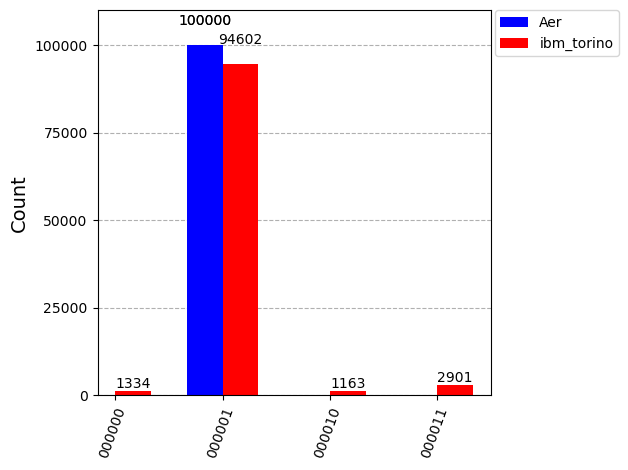

In [14]:
%matplotlib inline
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_circuit_layout
from qiskit.circuit.library import UnitaryGate,QFTGate
import numpy as np
import matplotlib.pyplot as plt
from qiskit_ibm_runtime import QiskitRuntimeService,SamplerV2

#Defining the backend 
"""service = QiskitRuntimeService()
backend_name = 'ibm_torino'
sim_ibm = service.backend(backend_name)"""

p = 0.998489
q = 0.119545

shots = 100000
A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)], [np.sqrt(1-p), -np.sqrt(p)]]), label='A')
B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)], [np.sqrt(1-q), -np.sqrt(q)]]), label='B')

qc = QuantumCircuit(6,6)
qc.append(QFTGate(2), [0, 1])
qc.swap(0,1)
for i in range(2):
    qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)

qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()

qc.p(np.pi,3)
qc.p(np.pi/2,4)
qc.barrier()

qc.swap(3, 0)
qc.swap(4, 1)
qc.swap(5, 2)


for j in range(18):
    if j % 4 == 0 or j % 4 == 1:
        qc.append(A,[2])
    else:
        qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)  
qc.swap(0,1)
qc.append(QFTGate(2), [0, 1]).inverse()
qc.barrier()
qc.measure([0,1],[0,1])

#qc_ibm = transpile(qc, backend= sim_ibm,optimization_level=3)
simulator = AerSimulator()

qc_t = transpile(qc, backend=simulator)
#Implementing in ibm
"""from qiskit import QuantumRegister
qreg = QuantumRegister(6,'q')
layout = {qreg[0]: 11, qreg[1]: 12, qreg[2]: 18, qreg[3]: 91, qreg[4]: 95, qreg[5]: 96}
qc_ibm = transpile(qc,backend = sim_ibm, optimization_level=3, initial_layout = layout)
sampler = SamplerV2(mode = sim_ibm)

job_ibm = sampler.run([qc_ibm], shots=100000)"""
#Retrieving the job run in ibm
service = QiskitRuntimeService(
    channel='ibm_quantum_platform',
    instance='crn:v1:bluemix:public:quantum-computing:us-east:a/de44b638ece2480e8d1b9d89c9dcdeb3:0cd77911-7ffd-4c1d-9324-1e549404bb77::'
)
job = service.job('d6057dt7fc0s73aun5cg')
result_ibm = job.result()
counts_ibm = result_ibm[0].data.c.get_counts()

# Run simulations
result = simulator.run(qc_t, shots=100000).result()
counts = result.get_counts()
#plot_histogram(counts)
plot_histogram([counts,counts_ibm],legend = ["Aer","ibm_torino"],color = ['blue','red'])
print("IBM:", counts_ibm)
print("Aer:", counts)
#print("Depth ibm:", qc_ibm.depth())
#print("Depth in Aer: ", qc_t.depth)

#qc.draw('mpl')
#print(qc_ibm.depth())
#qc_ibm.draw('mpl',idle_wires=False)
#plot_circuit_layout(qc_ibm, sim_ibm)
plt.show()


IBM: {'000001': 59664, '000011': 24909, '000010': 7900, '000000': 7527}
Aer: {'000001': 100000}


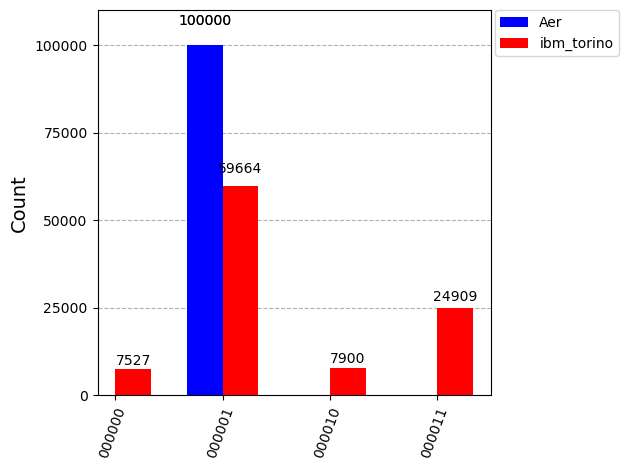

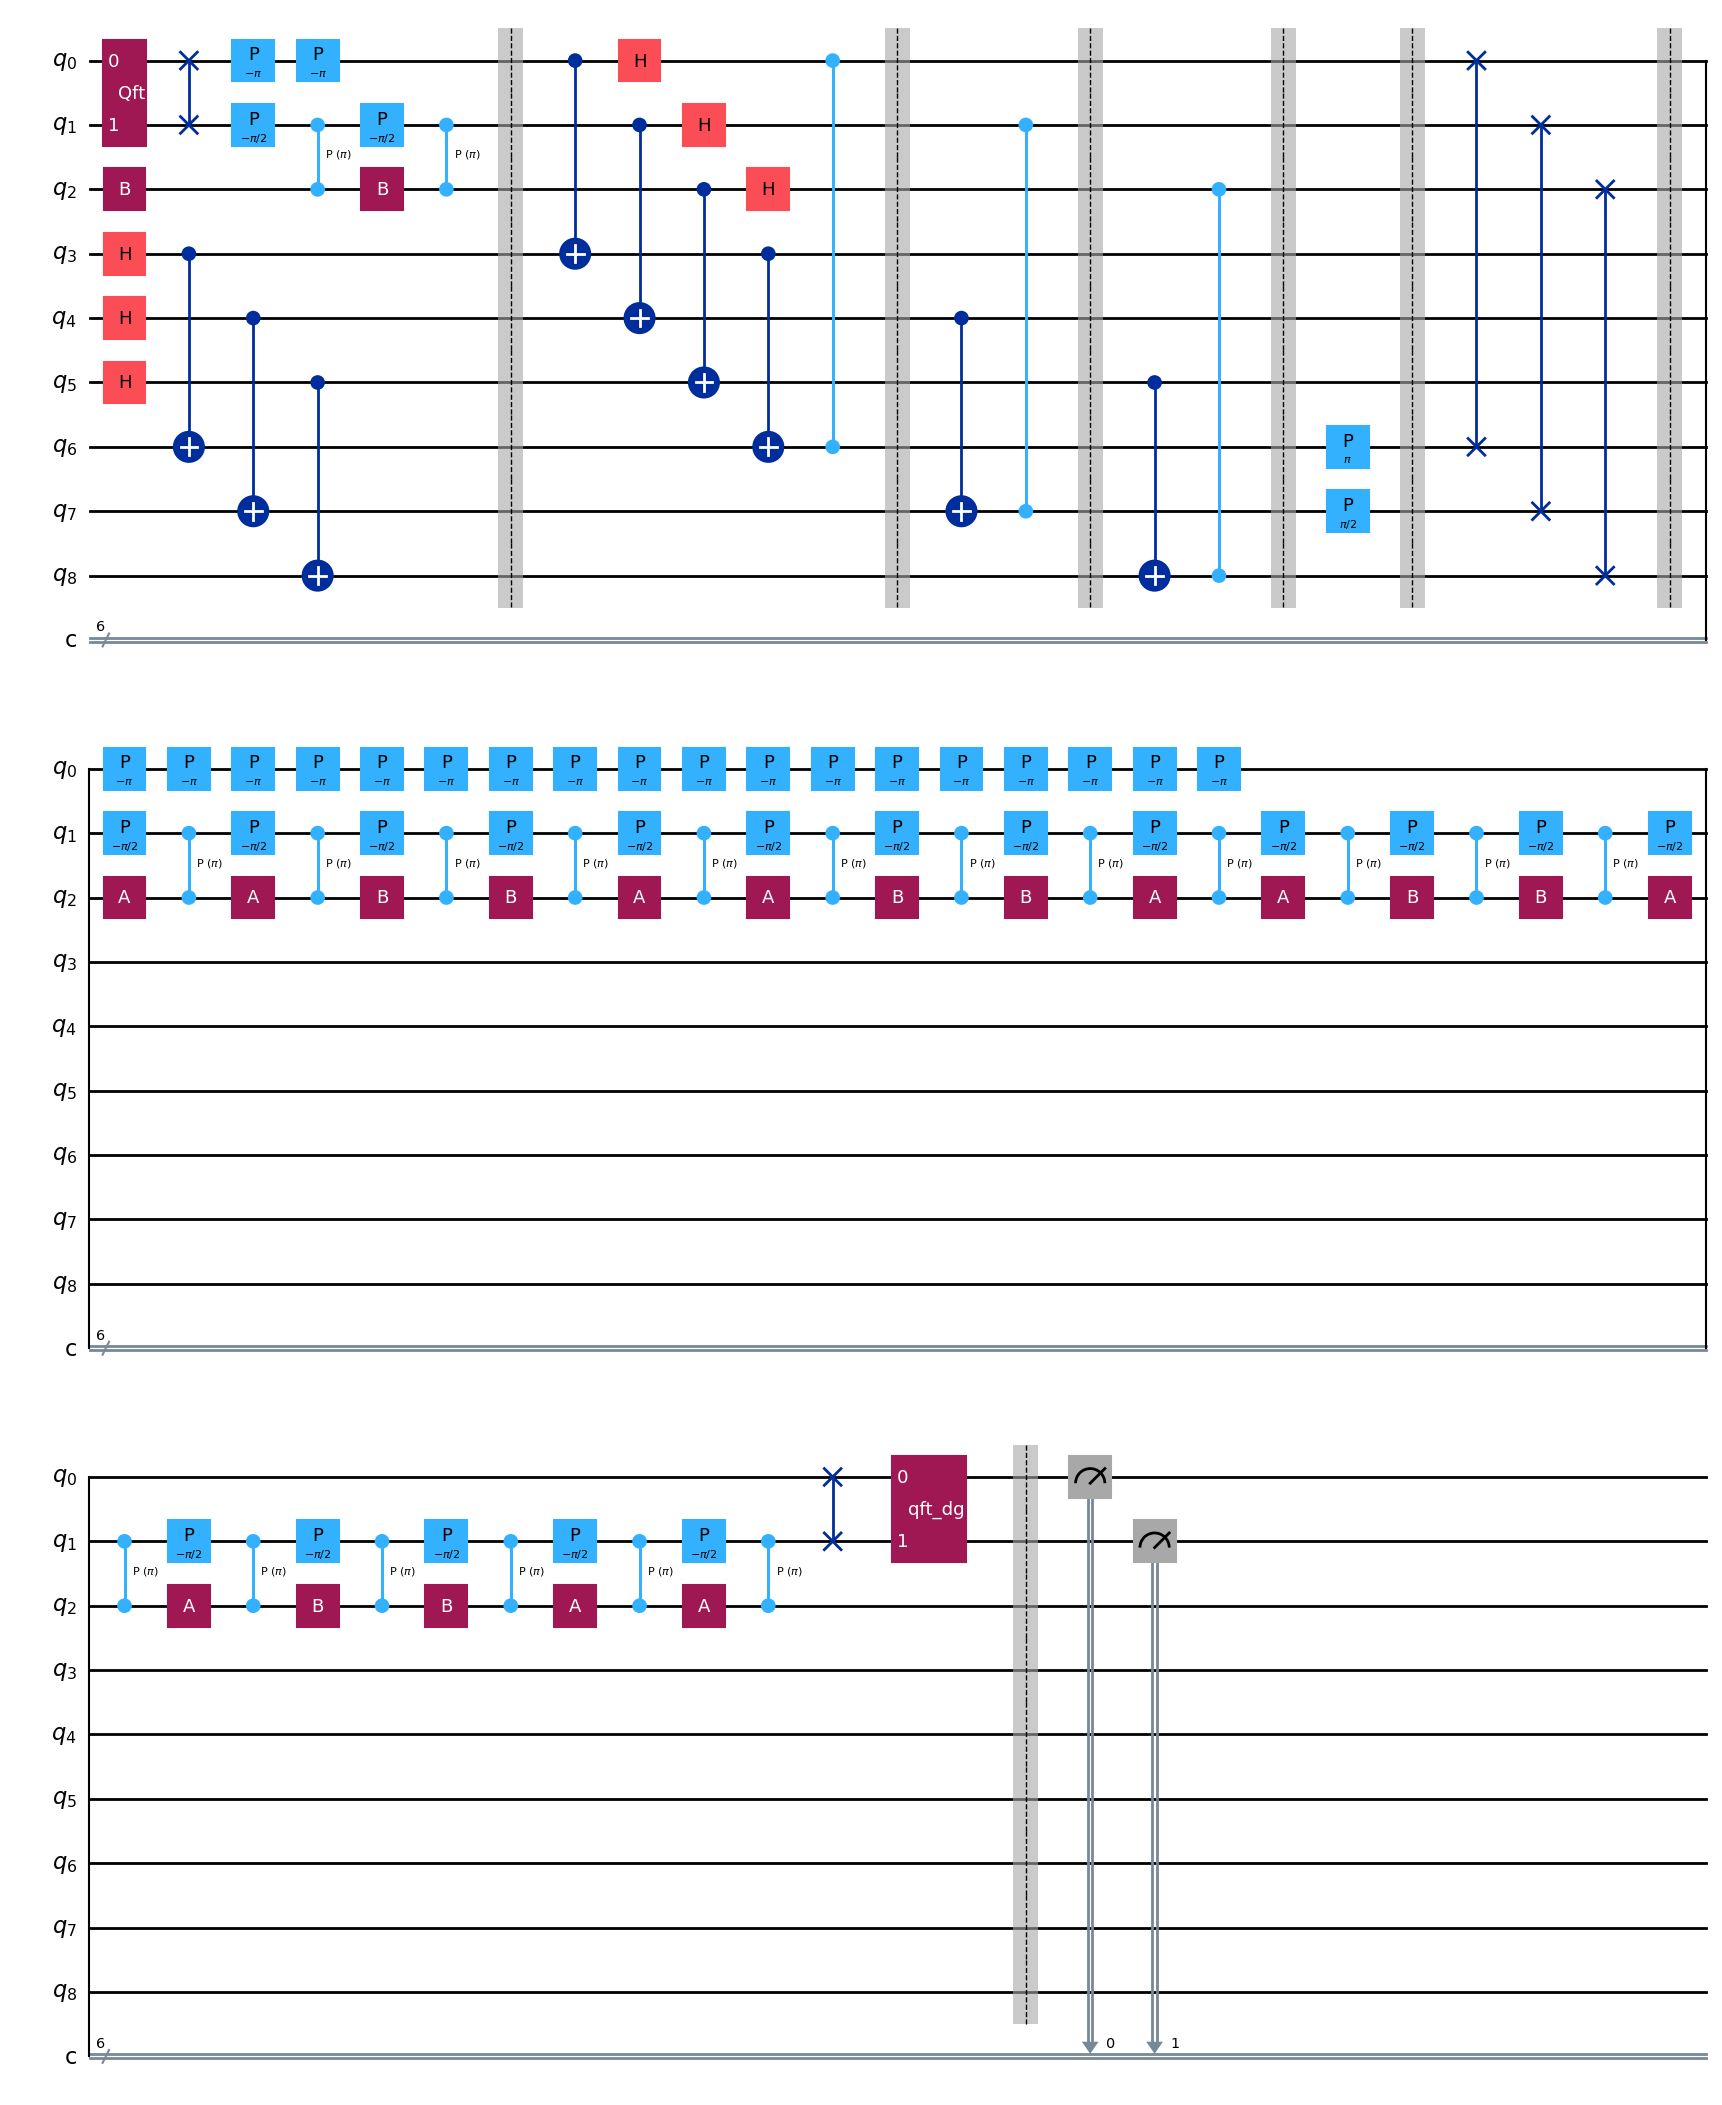

In [15]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, noise
import numpy as np
from qiskit.circuit.library import QFTGate, UnitaryGate
from qiskit_ibm_runtime import QiskitRuntimeService,SamplerV2
from qiskit.visualization import plot_histogram, plot_circuit_layout
import matplotlib.pyplot as plt
#Defining the backend 
"""
service = QiskitRuntimeService()
backend_name = 'ibm_torino'
sim_ibm = service.backend(backend_name)"""

shots = 100000
p = 0.998489
q = 0.119545

A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)], [np.sqrt(1-p), -np.sqrt(p)]]), label='A')
B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)], [np.sqrt(1-q), -np.sqrt(q)]]), label='B')

qc = QuantumCircuit(9,6)

qc.h(3)
qc.cx(3,6)
qc.h(4)
qc.cx(4,7)
qc.h(5)
qc.cx(5,8)

qc.append(QFTGate(2), [0, 1])
qc.swap(0,1)
for i in range(2):
    qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)

qc.barrier()

qc.cx(0,3)
qc.h(0)
qc.cx(1,4)
qc.h(1)
qc.cx(2,5)
qc.h(2)

qc.cx(3,6)
qc.cz(0,6)
qc.barrier()
qc.cx(4,7)
qc.cz(1,7)
qc.barrier()
qc.cx(5,8)
qc.cz(2,8)
qc.barrier()


qc.p(np.pi,6)
qc.p(np.pi/2,7)

qc.barrier()

qc.swap(6,0)
qc.swap(7,1)
qc.swap(8,2)
qc.barrier()
for j in range(18):
    if j % 4 == 0 or j % 4 == 1:
        qc.append(A,[2])
    else:
        qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)  
qc.swap(0,1)
qc.append(QFTGate(2), [0, 1]).inverse()
qc.barrier()
qc.measure([0,1],[0,1])

simulator = AerSimulator()

qc_t = transpile(qc, backend=simulator)
#Implementing in ibm
"""
from qiskit import QuantumRegister
qreg = QuantumRegister(9,'q')
layout = {qreg[0]: 11, qreg[1]: 12, qreg[2]: 18, qreg[3]: 31, qreg[4]: 30, qreg[5]: 29, qreg[6]: 91, qreg[7]: 95, qreg[8]: 96}
qc_ibm = transpile(qc,backend = sim_ibm, optimization_level=3,initial_layout=layout)
#qc_ibm = transpile(qc,backend = sim_ibm, optimization_level=3)
sampler = SamplerV2(mode = sim_ibm)

job_ibm = sampler.run([qc_ibm], shots=100000)"""
#Retrieving the job run in ibm
service = QiskitRuntimeService(
    channel='ibm_quantum_platform',
    instance='crn:v1:bluemix:public:quantum-computing:us-east:a/de44b638ece2480e8d1b9d89c9dcdeb3:0cd77911-7ffd-4c1d-9324-1e549404bb77::'
)
job_ibm = service.job('d610du7s6ggc73fetq0g')
result_ibm = job_ibm.result()
counts_ibm = result_ibm[0].data.c.get_counts()

# Run simulations
result = simulator.run(qc_t, shots=100000).result()
counts = result.get_counts()
#plot_histogram(counts)
plot_histogram([counts,counts_ibm],legend = ["Aer","ibm_torino"],color = ['blue','red'])
print("IBM:", counts_ibm)
print("Aer:", counts)
#print("Depth ibm:", qc_ibm.depth())
#print("Depth in Aer: ", qc_t.depth)

qc.draw('mpl')
#print(qc_ibm.depth())
#qc_ibm.draw('mpl',idle_wires=False)
#plot_circuit_layout(qc_ibm, sim_ibm)
plt.show()


In [17]:
#Saving ibm account
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token="ZBF5qVeB77HDvVCTnTIanUPqjlXmLrBvmMYw5UoPP-6U" ,overwrite=True)

# SWAP then Teleport (fig 19(c))

IBM: {'000001': 58020, '000000': 12288, '000011': 18875, '000010': 10817}
Aer: {'000001': 100000}


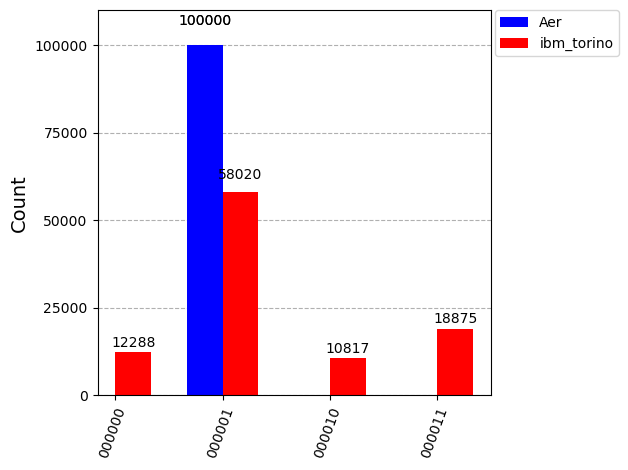

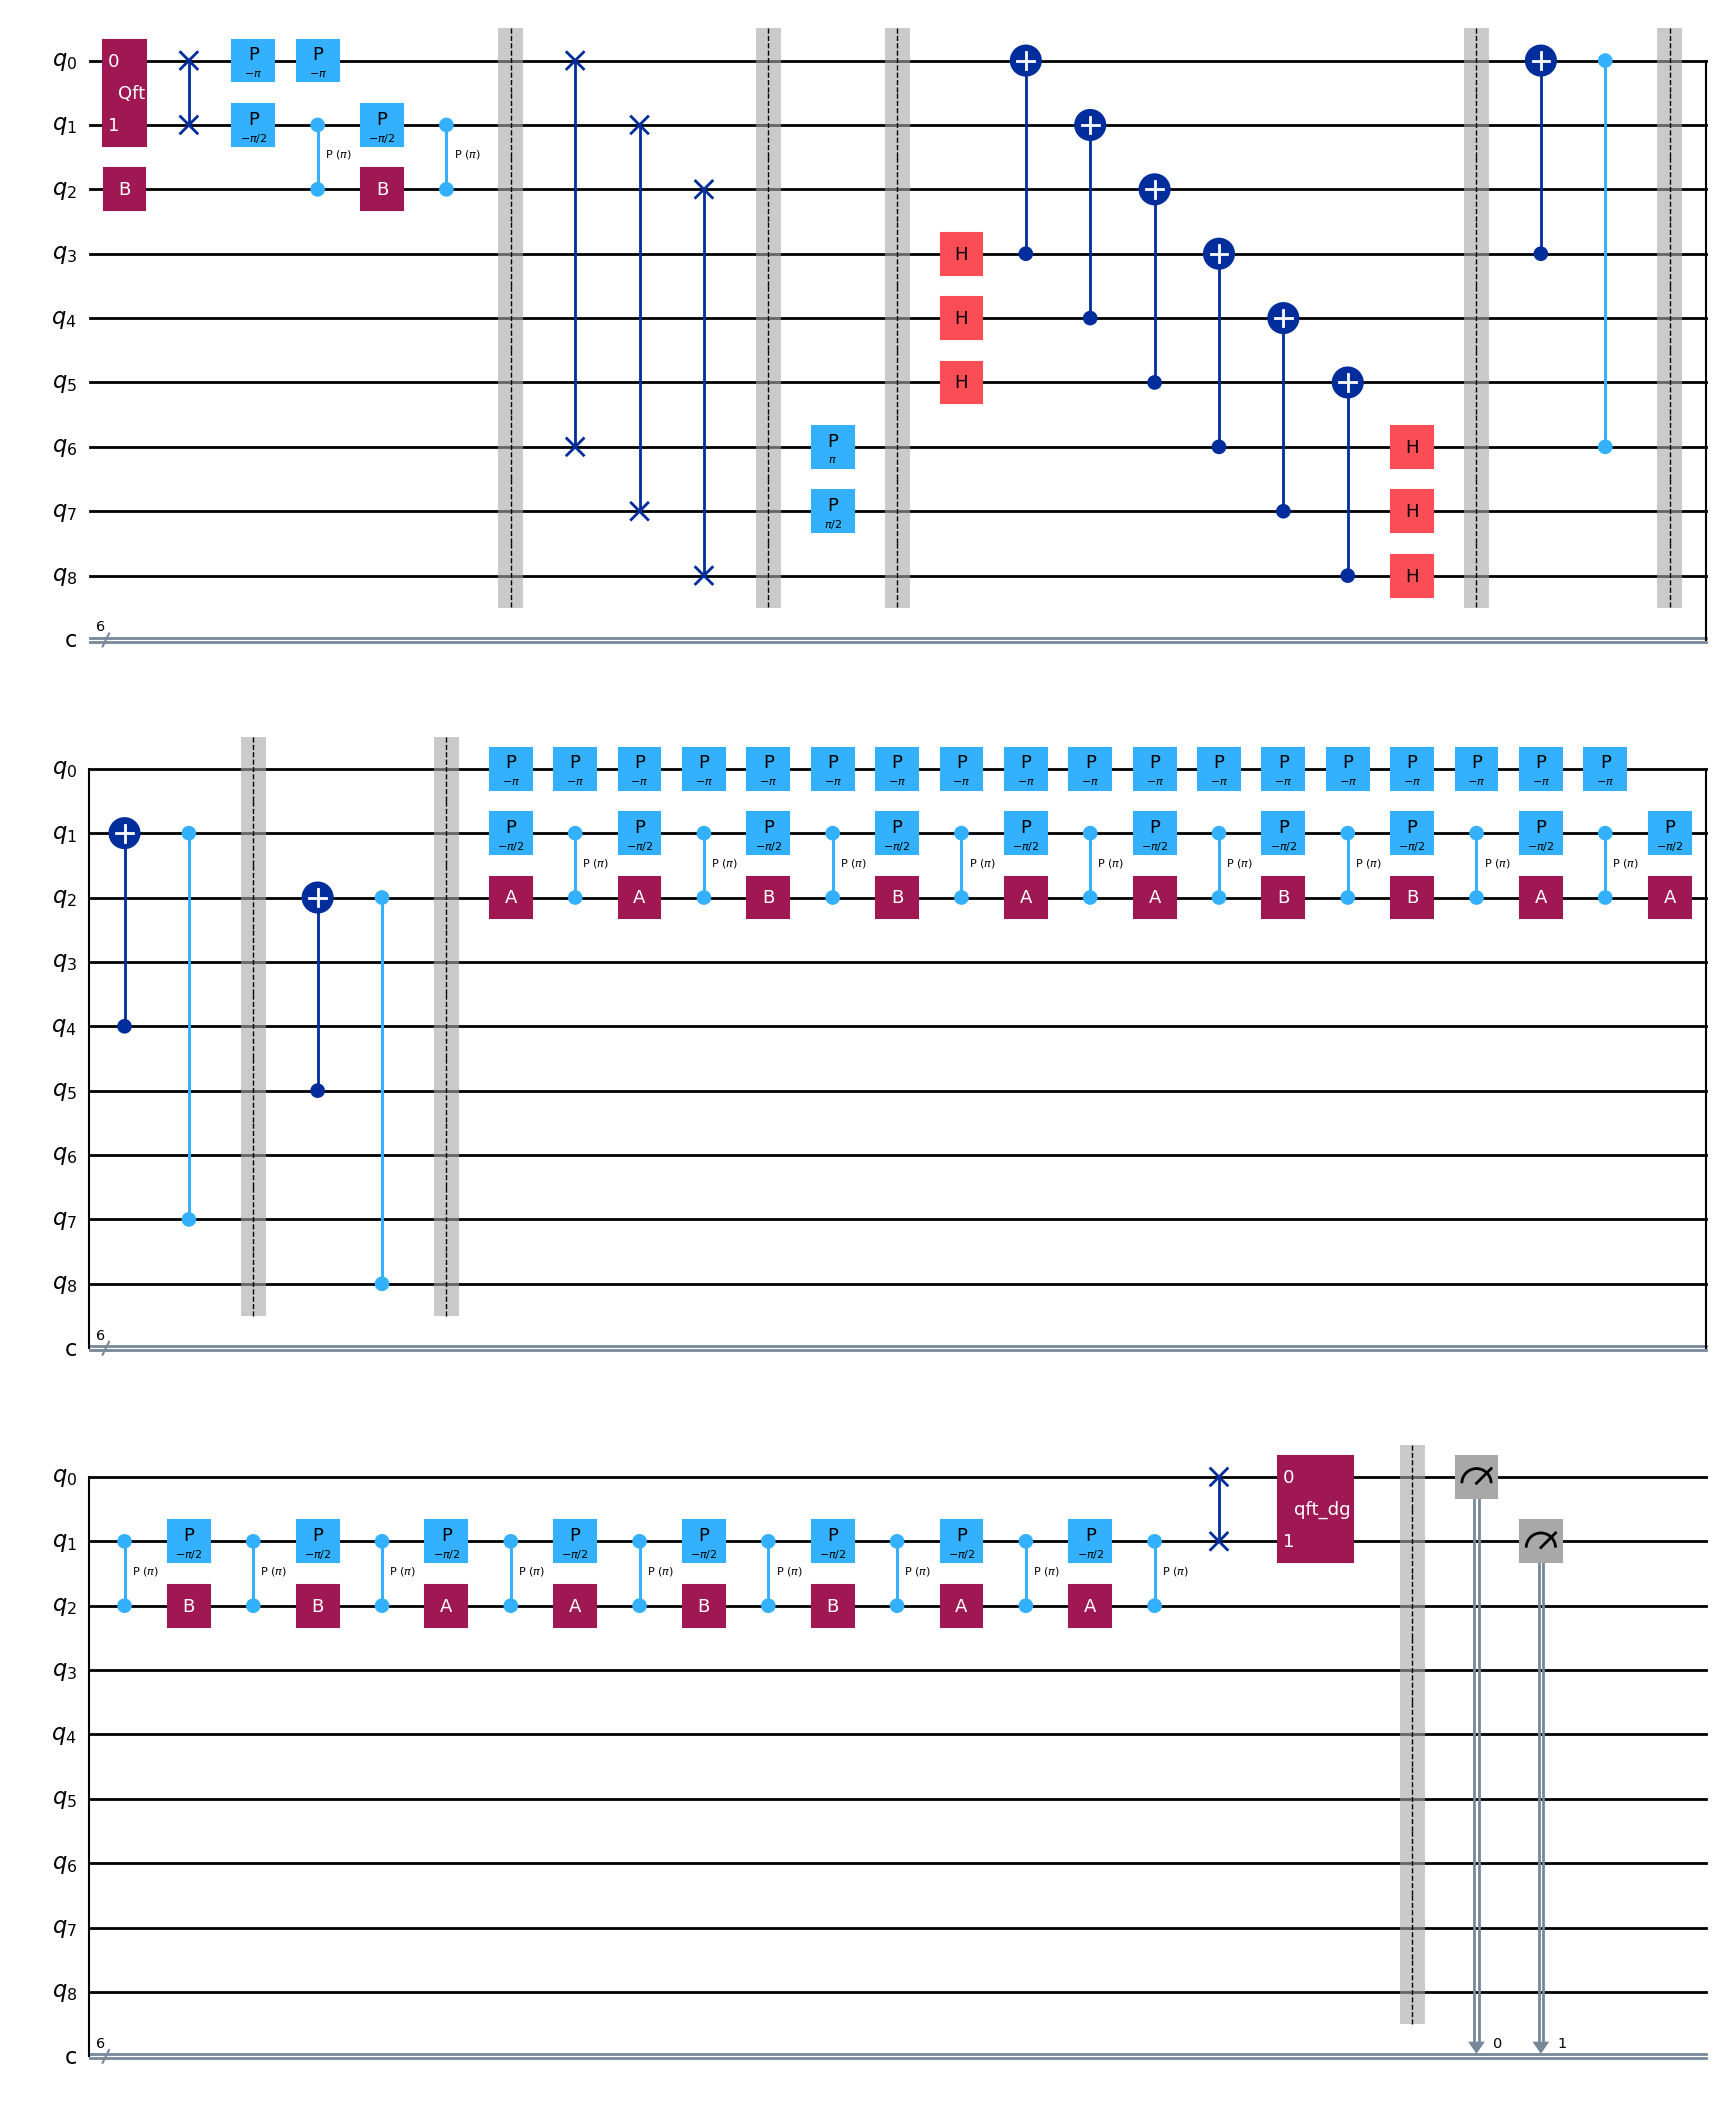

In [18]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, noise
import numpy as np
from qiskit.circuit.library import QFTGate, UnitaryGate
from qiskit_ibm_runtime import QiskitRuntimeService,SamplerV2
from qiskit.visualization import plot_histogram, plot_circuit_layout
import matplotlib.pyplot as plt
#Defining the backend
"""service = QiskitRuntimeService()
backend_name = 'ibm_torino'
sim_ibm = service.backend(backend_name)"""

shots = 100000
p = 0.998489
q = 0.119545

A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)], [np.sqrt(1-p), -np.sqrt(p)]]), label='A')
B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)], [np.sqrt(1-q), -np.sqrt(q)]]), label='B')

qc = QuantumCircuit(9,6)


qc.append(QFTGate(2), [0, 1])
qc.swap(0,1)
for i in range(2):
    qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)

qc.barrier()

qc.swap(0, 6)
qc.swap(1, 7)
qc.swap(2, 8)
qc.barrier()

qc.p(np.pi,6)
qc.p(np.pi/2,7)

qc.barrier()

qc.h(3)
qc.cx(3,0)
qc.h(4)
qc.cx(4,1)
qc.h(5)
qc.cx(5,2)

qc.cx(6,3)
qc.h(6)
qc.cx(7,4)

qc.h(7)
qc.cx(8,5)
qc.h(8)
qc.barrier()
qc.cx(3,0)
qc.cz(6,0)
qc.barrier()
qc.cx(4,1)
qc.cz(7,1)
qc.barrier()
qc.cx(5,2)
qc.cz(8,2)

qc.barrier()

for j in range(18):
    if j % 4 == 0 or j % 4 == 1:
        qc.append(A,[2])
    else:
        qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)  
qc.swap(0,1)
qc.append(QFTGate(2), [0, 1]).inverse()
qc.barrier()
qc.measure([0,1],[0,1])

simulator = AerSimulator()

qc_t = transpile(qc, backend=simulator)
#Implementing in ibm
"""from qiskit import QuantumRegister
qreg = QuantumRegister(9,'q')
layout = {qreg[0]: 3, qreg[1]: 4, qreg[2]: 5, qreg[3]: 11, qreg[4]: 12, qreg[5]: 18, qreg[6]: 29, qreg[7]: 30, qreg[8]: 31}
qc_ibm = transpile(qc,backend = sim_ibm, optimization_level=3,initial_layout=layout)
sampler = SamplerV2(mode = sim_ibm)

job_ibm = sampler.run([qc_ibm], shots=100000)"""
#retrieving the job run in ibm
service = QiskitRuntimeService(
    channel='ibm_quantum_platform',
    instance='crn:v1:bluemix:public:quantum-computing:us-east:a/1a3078bb3f6b416b939bf4197a950881:4a3c5393-2587-403f-8b37-e6092af20dd6::'
)
job_ibm = service.job('d62ojcjc4tus73fdnqbg')
result_ibm = job_ibm.result()
counts_ibm = result_ibm[0].data.c.get_counts()

# Run simulations
result = simulator.run(qc_t, shots=100000).result()
counts = result.get_counts()
#plot_histogram(counts)
plot_histogram([counts,counts_ibm],legend = ["Aer","ibm_torino"],color = ['blue','red'])
print("IBM:", counts_ibm)
print("Aer:", counts)
#print("Depth ibm:", qc_ibm.depth())
#print("Depth in Aer: ", qc_t.depth)

qc.draw('mpl')
#print(qc_ibm.depth())
#qc_ibm.draw('mpl',idle_wires=False)
#plot_circuit_layout(qc_ibm, sim_ibm)
plt.show()